## 1. Setup and Load the Dataset

The training CSV is used for the main analysis because it contains the `label_group` that represents product identity. The test CSV is inspected only to understand its available columns.

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from collections import Counter



train = pd.read_csv(r'D:\weq-preview\madatory task 1\train.csv')
test = pd.read_csv(r'D:\weq-preview\madatory task 1\test.csv')

print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("\nTrain columns:", train.columns.tolist())
print("Test columns :", test.columns.tolist())

Train shape: (34250, 5)
Test shape : (3, 4)

Train columns: ['posting_id', 'image', 'image_phash', 'title', 'label_group']
Test columns : ['posting_id', 'image', 'image_phash', 'title']


## 2. Understand the Dataset

From the columns:
- `posting_id`: identifier for a listing.
- `image`: image filename/identifier for the listing.
- `image_phash`: perceptual hash associated with the image.
- `title`: text description/title of the listing.
- `label_group`: product-group identifier. Listings with the same `label_group` belong to the same product group in the labelled training data.

The matching relationship is therefore represented by whether two training listings have the same `label_group`.

In [2]:
display(train.head())
print("\nData types:")
display(train.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(train.isna().sum().to_frame("missing"))

print("\nNumber of unique values:")
display(train.nunique().to_frame("unique_values"))

print("\nExample test rows:")
display(test.head())

,posting_id,image,image_phash,title,label_group
0,train_129225211,0000a68812bc7e98c42888dfb1c07da0.jpg,94974f937d4c2433,Paper Bag Victoria Secret,249114794
1,train_3386243561,00039780dfc94d01db8676fe789ecd05.jpg,af3f9460c2838f0f,"Double Tape 3M VHB 12 mm x 4,5 m ORIGINAL / DO...",2937985045
2,train_2288590299,000a190fdd715a2a36faed16e2c65df7.jpg,b94cb00ed3e50f78,Maling TTS Canned Pork Luncheon Meat 397 gr,2395904891
3,train_2406599165,00117e4fc239b1b641ff08340b429633.jpg,8514fc58eafea283,Daster Batik Lengan pendek - Motif Acak / Camp...,4093212188
4,train_3369186413,00136d1cf4edede0203f32f05f660588.jpg,a6f319f924ad708c,Nescafe \xc3\x89clair Latte 220ml,3648931069



Data types:


,dtype
posting_id,str
image,str
image_phash,str
title,str
label_group,int64



Missing values:


,missing
posting_id,0
image,0
image_phash,0
title,0
label_group,0



Number of unique values:


,unique_values
posting_id,34250
image,32412
image_phash,28735
title,33117
label_group,11014



Example test rows:


,posting_id,image,image_phash,title
0,test_2255846744,0006c8e5462ae52167402bac1c2e916e.jpg,ecc292392dc7687a,Edufuntoys - CHARACTER PHONE ada lampu dan mus...
1,test_3588702337,0007585c4d0f932859339129f709bfdc.jpg,e9968f60d2699e2c,(Beli 1 Free Spatula) Masker Komedo | Blackhea...
2,test_4015706929,0008377d3662e83ef44e1881af38b879.jpg,ba81c17e3581cabe,READY Lemonilo Mie instant sehat kuah dan goreng


## 3. Dataset Statistics

This section calculates the required:
- number of product listings
- number of unique product groups
- distribution of product-group sizes
- number of unique images
- duplicate images
- duplicate/highly similar titles
- title-length distribution
- additional useful properties

In [3]:
# Required statistics
num_listings = len(train)
num_groups = train["label_group"].nunique()

group_sizes = train.groupby("label_group").size()
num_unique_images = train["image"].nunique()
duplicate_image_rows = train["image"].duplicated().sum()

num_unique_phash = train["image_phash"].nunique()
duplicate_phash_rows = train["image_phash"].duplicated().sum()

num_unique_titles = train["title"].nunique()
duplicate_title_rows = train["title"].duplicated().sum()

title_lengths = train["title"].str.len()

stats = pd.Series({
    "Number of product listings": num_listings,
    "Number of unique product groups": num_groups,
    "Average listings per product group": group_sizes.mean(),
    "Largest product-group size": group_sizes.max(),
    "Number of unique image names": num_unique_images,
    "Duplicate image-name rows": duplicate_image_rows,
    "Number of unique image pHashes": num_unique_phash,
    "Duplicate pHash rows": duplicate_phash_rows,
    "Number of unique titles": num_unique_titles,
    "Duplicate title rows": duplicate_title_rows,
    "Average title length": title_lengths.mean(),
    "Shortest title length": title_lengths.min(),
    "Longest title length": title_lengths.max(),
})
display(stats.to_frame("value"))

print("Product-group size distribution:")
display(group_sizes.describe().to_frame("group_size"))

,value
Number of product listings,34250.000000
Number of unique product groups,11014.000000
Average listings per product group,3.109679
Largest product-group size,51.000000
Number of unique image names,32412.000000
Duplicate image-name rows,1838.000000
Number of unique image pHashes,28735.000000
Duplicate pHash rows,5515.000000
Number of unique titles,33117.000000
Duplicate title rows,1133.000000


Product-group size distribution:


,group_size
count,11014.000000
mean,3.109679
std,2.940827
min,2.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,51.000000


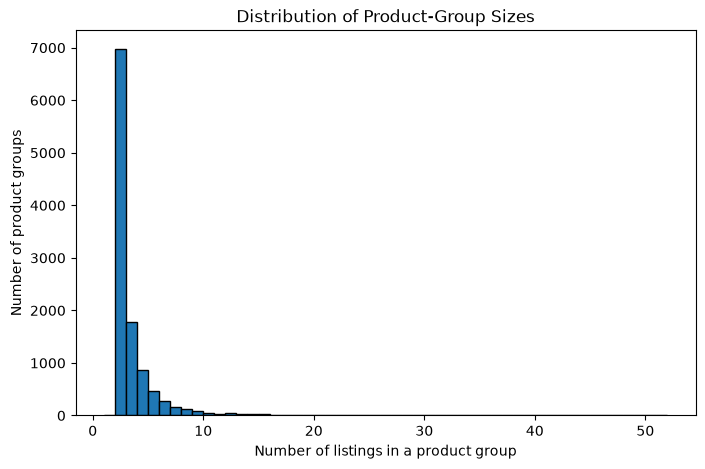

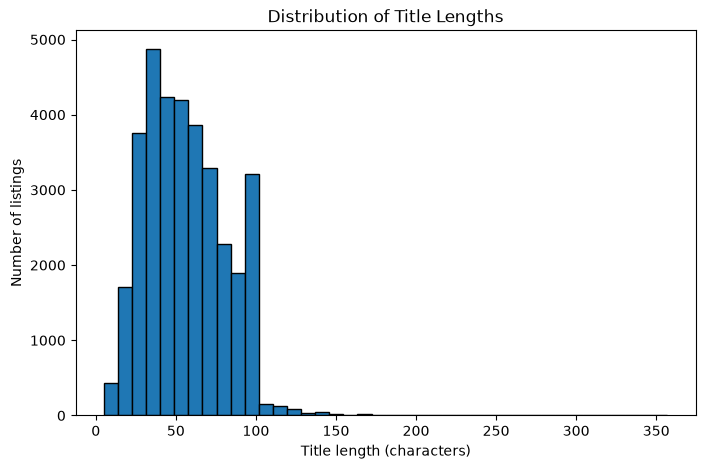

In [4]:
# Distribution of product-group sizes
plt.figure(figsize=(8, 5))
plt.hist(group_sizes, bins=range(1, group_sizes.max() + 2), edgecolor="black")
plt.xlabel("Number of listings in a product group")
plt.ylabel("Number of product groups")
plt.title("Distribution of Product-Group Sizes")
plt.show()

# Title length distribution
plt.figure(figsize=(8, 5))
plt.hist(title_lengths, bins=40, edgecolor="black")
plt.xlabel("Title length (characters)")
plt.ylabel("Number of listings")
plt.title("Distribution of Title Lengths")
plt.show()

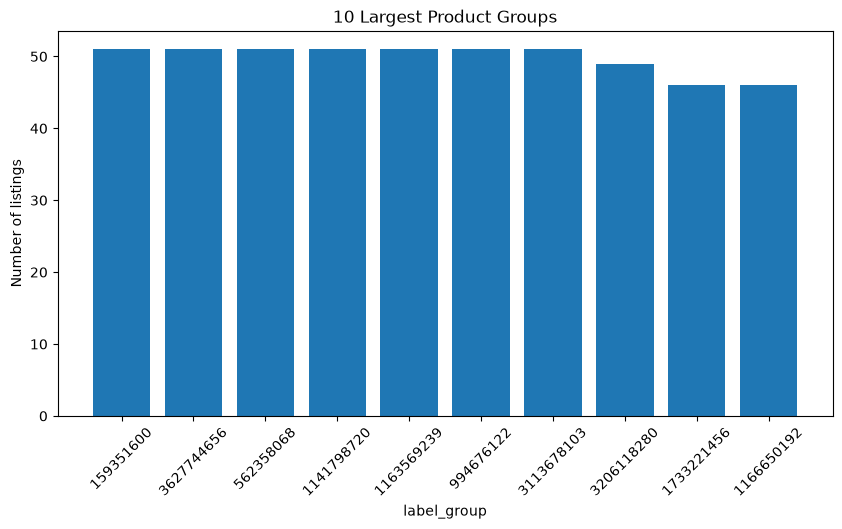

,listing_count
label_group,
159351600,51
3627744656,51
562358068,51
1141798720,51
1163569239,51
994676122,51
3113678103,51
3206118280,49
1733221456,46


In [5]:
# Top product groups by number of listings
top_groups = group_sizes.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_groups.index.astype(str), top_groups.values)
plt.xlabel("label_group")
plt.ylabel("Number of listings")
plt.title("10 Largest Product Groups")
plt.xticks(rotation=45)
plt.show()

display(top_groups.rename("listing_count").to_frame())

## 4. Duplicate and Highly Similar Titles

Exact duplicate titles are measured directly. For highly similar titles, character n-gram TF-IDF cosine similarity is used only to **inspect examples**, not to build the final matching system.

We specifically look for:
1. similar titles belonging to the same product group;
2. similar titles belonging to different product groups.

The second case is especially important because it shows why title text alone may produce false matches.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Exact duplicate titles
exact_title_duplicates = train[train["title"].duplicated(keep=False)].sort_values("title")
print("Exact duplicate title rows:", len(exact_title_duplicates))
display(exact_title_duplicates[["posting_id", "title", "label_group"]].head(20))

# Character n-gram similarity for a manageable sample of unique titles.
# This is for exploration/examples only.
sample_n = min(10000, len(train))
title_sample = train.sample(sample_n, random_state=42).reset_index(drop=True)

vectorizer = TfidfVectorizer(analyzer="char", ngram_range=(3, 5), min_df=2)
X_title = vectorizer.fit_transform(title_sample["title"].fillna(""))

# Find the most similar pair for each sampled title without creating a huge full matrix.
def top_similar_title_pairs(X, df, top_k=20):
    rows = []
    for i in range(X.shape[0]):
        sims = cosine_similarity(X[i], X).ravel()
        sims[i] = -1
        j = int(np.argmax(sims))
        rows.append((i, j, sims[j]))
    pairs = pd.DataFrame(rows, columns=["i", "j", "similarity"])
    pairs = pairs[pairs["i"] < pairs["j"]]
    pairs["same_group"] = (
        df.iloc[pairs["i"].values]["label_group"].to_numpy()
        == df.iloc[pairs["j"].values]["label_group"].to_numpy()
    )
    return pairs.sort_values("similarity", ascending=False).head(top_k)

pairs = top_similar_title_pairs(X_title, title_sample, top_k=100)

same_group_pairs = pairs[pairs["same_group"]].head(10)
different_group_pairs = pairs[~pairs["same_group"]].head(10)

print("Highly similar titles from the same product group:")
for _, r in same_group_pairs.iterrows():
    a, b = int(r.i), int(r.j)
    print(f"Similarity={r.similarity:.3f} | group={title_sample.loc[a, 'label_group']}")
    print(" A:", title_sample.loc[a, "title"])
    print(" B:", title_sample.loc[b, "title"])
    print()

print("\nHighly similar titles from different product groups:")
for _, r in different_group_pairs.iterrows():
    a, b = int(r.i), int(r.j)
    print(f"Similarity={r.similarity:.3f} | groups={title_sample.loc[a, 'label_group']} vs {title_sample.loc[b, 'label_group']}")
    print(" A:", title_sample.loc[a, "title"])
    print(" B:", title_sample.loc[b, "title"])
    print()

Exact duplicate title rows: 2095


,posting_id,title,label_group
12874,train_1575268265,( 1KG = 5 PCS ) DAISHA GAMIS TANPA INNER DALAMAN,4060702395
30948,train_1280553309,( 1KG = 5 PCS ) DAISHA GAMIS TANPA INNER DALAMAN,4060702395
26315,train_3266714293,(2 Warna) JSK 9101 JSK 9100 Custom Ripped Skin...,502958080
29607,train_2961850832,(2 Warna) JSK 9101 JSK 9100 Custom Ripped Skin...,502958080
16086,train_4062952348,(2KG) SHENAR RAK BUKU 3D 1X5 SUSUN ZAMAN NOW,1245245655
26695,train_2876255851,(2KG) SHENAR RAK BUKU 3D 1X5 SUSUN ZAMAN NOW,3314259214
30317,train_1018366203,(COD) Jam Hp onix U9/ DZ09 (SMARTWATCH + BOX) ...,4044845496
30748,train_1177573553,(COD) Jam Hp onix U9/ DZ09 (SMARTWATCH + BOX) ...,4044845496
25931,train_718861848,(ECER) LIPTINT SASIMI ALOEVERA 99%,1544174053
29369,train_3273191090,(ECER) LIPTINT SASIMI ALOEVERA 99%,1544174053


Highly similar titles from the same product group:
Similarity=1.000 | group=2671218489
 A: Sunsonic Pompa Air Galon Electric Tatakan Gelas Elektrik Water Pump CWP03 CWP 03 Terlaris
 B: Sunsonic Pompa Air Galon Electric Tatakan Gelas Elektrik Water Pump CWP03 CWP 03 Terlaris

Similarity=1.000 | group=2032670345
 A: B4E Mainan Anak Edukasi Lego Hanlo Tas isi 458 pcs Block Susun Pintar
 B: 4E Mainan Anak Edukasi Lego Hanlo Tas isi 458 pcs Block Susun Pintar

Similarity=1.000 | group=2093032547
 A: Somethinc CRIOUSLY 24K GOLD Essence (40ml)
 B: SOMETHINC Criously 24K Gold Essence (40ml)

Similarity=1.000 | group=2057614445
 A: HOT LIP BALM Krim Scrub Pelembab Bibir Anti Kering Kandungan Gel Propolis
 B: HOT LIP BALM Krim Scrub Pelembab Bibir Anti Kering Kandungan Gel Propolis

Similarity=1.000 | group=72307877
 A: dbE GM350 3.5mm Professional Gaming Headphone
 B: dbE GM350 3.5mm Professional Gaming Headphone

Similarity=1.000 | group=3230965030
 A: ATASAN MUNAFIE /BAJU MUNAFIE/ MUNAFIE BAJ

## 5. Product-Group Examples

A product group contains multiple listings that represent the same underlying product.

The examples below show groups with several listings and compare their titles/images. The notebook does not assume that identical titles or identical images are required for listings to belong to the same group.

In [7]:
# Show examples from the largest product groups
example_group_ids = group_sizes.sort_values(ascending=False).head(3).index

for gid in example_group_ids:
    print("=" * 100)
    print("PRODUCT GROUP:", gid)
    display(train[train["label_group"] == gid][
        ["posting_id", "image", "image_phash", "title", "label_group"]
    ].head(10))

PRODUCT GROUP: 159351600


,posting_id,image,image_phash,title,label_group
1167,train_207039286,09165142230c0d600c02a66f62dbee5d.jpg,8b1cbc63e330c69d,Ready Stock - Gluta Collagen Soap By Beautetox...,159351600
2069,train_1619338643,0ff3d417c454a614596da0f160e85b83.jpg,e3d894276a58c1de,GLUTA COLLAGEN SOAP BY BEAUTETOX SKINSUPERSTAR,159351600
2542,train_3721308865,136d7ea9fefe1cc04b6a8dfd965cbc9e.jpg,faad9752e4991162,KIRIM SETIAP HARI!! GLUTA COLLAGEN SOAP BEAUTE...,159351600
3140,train_1851882944,18244a8fdbb3aa0b5afb6c31d99134a5.jpg,e893a3d4a48d3973,[Ready & Resmi] Gluta Soap Beautetox Viral,159351600
3989,train_1236075269,1e4b5a9adc92e50df500e24d935fe0db.jpg,a0c4be17b3393693,READY STOK [THE3ANGLE-KD] Gluta Collagen Beaut...,159351600
4024,train_2855329700,1e8f09fca97fca7c88a25afa618a10ff.jpg,b90ee0f1c6733b12,[READY SIAP KIRIM] GLUTA COLLAGEN SOAP,159351600
4823,train_1997808959,24735427cab6ac1eb36180269ce0168e.jpg,ab6994b4b66a69c8,(DISKON 11-11 BURUAN ORDER) Sabun Whitening Gl...,159351600
4927,train_2840508723,25313d734a75035935dfc008aa0fc833.jpg,c0f79394b441afaa,[FREE JARING SABUN] Gluta Collagen Soap [READY],159351600
5489,train_2729160884,296d7b2a49d7e94fbde30b9bf7d75447.jpg,94196fc571522f35,GLUTA COLLAGEN SOAP (ready) free jaring sabun,159351600
5946,train_2902736490,2d0e11ade5ccb02845e71f27fd671ebd.jpg,c993a7ca34c49d33,READY STOCK FREE GIFT GLUTA COLLAGEN SOAP BEAU...,159351600


PRODUCT GROUP: 3627744656


,posting_id,image,image_phash,title,label_group
306,train_4206743389,027478fc15b3caf7d9be5465ad7bdf5c.jpg,c20e7a338f3ad471,IMPLORA CHEEK & LIPTINT - IMPLORA LIP TINT ORI...,3627744656
836,train_984412308,06a30c1186bba5d8bd43a0b7ea82f4ab.jpg,ed8ff8d49a390429,IMPLORA CHEEK & LIPTINT,3627744656
1196,train_121852154,0941ac21685c9063892a57fff8f0140a.jpg,9385847b53950ef3,Lip Tint Implora Cheek & Liptint,3627744656
1901,train_762535630,0eaa1b8b75d0f63a5a9a68cedbb0401e.jpg,acb803a3c3c3e96d,IMPLORA Cheek & Lip Tint Model Ice Cream - Set...,3627744656
3088,train_3517115705,17bb01d212b763b11df333642e32a12e.jpg,fa6bb113623c9668,{Promo murah} Implora cheek&liptint,3627744656
3310,train_2262735115,19771208968bf82abc12ba013b893732.jpg,fa6bb113623c9668,Implora Cheek and Liptint/ Lip Tint implora,3627744656
4290,train_3755300225,20b8835e1c5e17afa50fb15f7331c862.jpg,b7ca1457a21d6356,IMPLORA CHEEK LIP TINT,3627744656
5515,train_368430234,29aee25986d77e1f19414bea8f4b7486.jpg,fa6bb113623c9668,New cheek dan Liptint/ lip tint by IMPLORA bpom,3627744656
6806,train_2317288464,336e246579cc675ebdd04c25a0bb8c42.jpg,b7c8145fa21d6356,Implora Cheek & Liptint - Implora Liptint - Li...,3627744656
7757,train_3208392688,3a88b089e147e18f9c9355224bfb8495.jpg,abecc290a53b94d3,NEW LIPTINT IMPLORA / IMPLORA CHEEK & LIPTINT,3627744656


PRODUCT GROUP: 562358068


,posting_id,image,image_phash,title,label_group
275,train_1251926547,0233d1522f95031e111d777739e9f1e9.jpg,a686c86331cd3fac,"VIVA Cleansing Milk, VIVA Air Mawar, VIVA Face...",562358068
731,train_576940044,05bbba6828fa60b2475581185592a6e2.jpg,cc91a56a9be26cc9,VIVA AIR MAWAR 100ML,562358068
732,train_2821917682,05bbba6828fa60b2475581185592a6e2.jpg,cc91a56a9be26cc9,Viva air mawar 100ml,562358068
2141,train_3942479788,107af60a2f111adfa929dc2b7ee01b14.jpg,e699996699666499,VIVA Air Mawar 100 ml,562358068
2144,train_2262165918,107d0ee856a261b74539ea41c8a20e29.jpg,b2e9ce16c16712d9,VIVA Air Mawar / Face Tonic / Milk Cleanser 10...,562358068
2987,train_2713325894,16e1873833325a939a017ecd2dcdaa0a.jpg,a68b8b05892766fb,VIVA Cosmetics Air Mawar 100ml,562358068
3086,train_4024729812,17b9151117d4271ae1b8713cfcd6426d.jpg,b2c9cb6499666699,VIVA Air Mawar 100 ml | Air Mawar Viva Pembersih,562358068
3592,train_3500331962,1b8d6aabc5d309af846a4c42de6a4023.jpg,e699996699266699,Viva Air Mawar Termurah 100% Original,562358068
3873,train_1833257672,1d7a43aba9849cd1059c43c1aaf2b6fd.jpg,e699996699336689,[ VIVA ] Air Mawar,562358068
4243,train_239849978,20603a3c19cff4fc48266b0d2012cae9.jpg,e699996699336689,Viva Air Mawar,562358068


## 6. Same Product Identity but Different Images

Within each product group, find examples where the image filename differs. If the pHash also differs, this gives a stronger example that the same product identity can have different image representations.

This is an important matching difficulty because the model cannot rely on exact image equality.

In [8]:
same_group_diff_image = (
    train.groupby("label_group")
         .filter(lambda g: g["image"].nunique() > 1)
         .sort_values("label_group")
)

# Prefer groups where pHash also differs
candidate_groups = (
    same_group_diff_image.groupby("label_group")
    .filter(lambda g: g["image_phash"].nunique() > 1)
)

display(candidate_groups[
    ["posting_id", "image", "image_phash", "title", "label_group"]
].head(20))

,posting_id,image,image_phash,title,label_group
3874,train_1646767365,1d7aadc7503b2b4539cc9a5fe41979dd.jpg,e925873ed09cd08f,Sarung celana wadimor original 100% dewasa dan...,258047
31859,train_1528423085,eec692257e74fcbc6cb63cb76d0f20e7.jpg,ea97861c926a71e3,WARNA RANDOM ACAK Sarung Celana Wadimor MURAH ...,258047
6738,train_398181303,3301b8aaccea93d1098995ffbc537335.jpg,e9b5833e929e909c,SARUNG CELANA WADIMOR DEWASA HITAM POLOS SARCEL,258047
7613,train_2865605743,3977f4e7a47c73568c5e9fcb61723b4b.jpg,bfc3cc1cc636c14c,Wall Sticker / WallSticker - Submarine Measur...,297977
12367,train_1382500866,5d075d7eaa258052ab125c75c06293d6.jpg,838436c07dff19e4,RELIZA WALL STICKER PENGUKUR TINGGI BADAN JERA...,297977
27972,train_2419208039,d173d12f8d2767512db31a01414047e4.jpg,c89817483f3f398e,LVN COLLAGEN / STROBERI,645628
15195,train_789743463,726574cf844c5dac0669f926d09c8931.jpg,c634f2e078e2b3cc,TERMURAH LVN COLLAGEN STROBERI 1 BOX 10 SACHET,645628
17455,train_320127748,8364a3398f498979f62065bb280b0c7c.jpg,b84e07f0c637b187,"LV.N COLLAGEN 1 BOX ""BELI ECER HARGA GROSIR"" O...",645628
20122,train_2587129863,96f576b30ec40414cc2eadb2be8e2d91.jpg,eb3d318d4bc61a25,[ORIGINAL] LVN COLLAGEN / POMEGLOW COLLAGEN 1 ...,645628
15610,train_2070644662,757c82b2781305c17d9384c48f76bb3a.jpg,8a71617a016e1efd,LVN COLLAGEN - ORIGINAL TERMURAH - LVN STROBER...,645628


## 7. Image Similarity: Visually Similar Images with Different Product Identities

The dataset provides `image_phash`, which can be compared using Hamming distance between hexadecimal pHash values.

A low Hamming distance means the image hashes are similar. We use this to find **candidate visually similar pairs with different `label_group` values**. These are useful examples of potential false matches.

If the actual image folder is available, the next cell can display the images.

In [13]:
def phash_to_bits(h):
    try:
        return bin(int(str(h), 16))[2:].zfill(len(str(h)) * 4)
    except (ValueError, TypeError):
        return None

# Work on unique pHashes to avoid repeated calculations.
phash_df = train[["image_phash", "label_group", "image", "posting_id", "title"]].drop_duplicates("image_phash").reset_index(drop=True)
bits = [phash_to_bits(x) for x in phash_df["image_phash"]]

valid = [i for i, b in enumerate(bits) if b is not None]
phash_df = phash_df.iloc[valid].reset_index(drop=True)
bits = [bits[i] for i in valid]

# Search a sample if the dataset is large.
max_compare = min(len(phash_df), 1000)
rng = np.random.default_rng(42)
idx = rng.choice(len(phash_df), max_compare, replace=False)
idx_set = set(idx)

visual_pairs = []
for pos_i, i in enumerate(idx):
    bi = bits[i]
    best = []
    for j in idx:
        if i == j:
            continue
        if phash_df.loc[i, "label_group"] == phash_df.loc[j, "label_group"]:
            continue
        bj = bits[j]
        d = sum(x != y for x, y in zip(bi, bj))
        best.append((d, i, j))
    best.sort(key=lambda x: x[0])
    visual_pairs.extend(best[:2])

visual_pairs = sorted(visual_pairs, key=lambda x: x[0])

seen = set()
rows = []
for d, i, j in visual_pairs:
    key = tuple(sorted((i, j)))
    if key in seen:
        continue
    seen.add(key)
    rows.append({
        "phash_hamming_distance": d,
        "posting_id_1": phash_df.loc[i, "posting_id"],
        "group_1": phash_df.loc[i, "label_group"],
        "image_1": phash_df.loc[i, "image"],
        "title_1": phash_df.loc[i, "title"],
        "posting_id_2": phash_df.loc[j, "posting_id"],
        "group_2": phash_df.loc[j, "label_group"],
        "image_2": phash_df.loc[j, "image"],
        "title_2": phash_df.loc[j, "title"],
    })
    if len(rows) >= 10:
        break

visual_similar_different_groups = pd.DataFrame(rows)
display(visual_similar_different_groups)

,phash_hamming_distance,posting_id_1,group_1,image_1,title_1,posting_id_2,group_2,image_2,title_2
0,4,train_2957438881,3578235866,41b2ce235949203532d1ce2651150902.jpg,\xe2\x9d\xa4\xef\xb8\x8fCOD\xe2\x9d\xa4\xef\xb...,train_2286676284,1378438916,f98f728161d02afce9d48b8f2c7cbad3.jpg,12 PCS/24pcs PER SET untuk fake nails atau fal...
1,8,train_2748854776,39246274,8a12fe9c4ee4264f3621616914791c48.jpg,Robot IronMan Spiderman Bumblebee C.America Da...,train_2112234201,1889967345,69da53e8a55d74efe47af1e77cac0cb1.jpg,AVENGERSS IRON MAN SMART DANCE ROBOT SUPER HER...
2,8,train_3023769589,221994575,93a64359e847a44730ee9177dcb6ae7f.jpg,"b""Johnson's (Clean & Fresh Bath) Active Kids 2...",train_1874278675,1680535208,438e69e38e62d800c598b34303c4dc39.jpg,Zoya Mix (Melon) Mama Bear Pelancar Asi
3,8,train_3649138806,728211574,2a2b3c8faccd5d3b486cf9bf1f83e42a.jpg,Strawberry - ST3520 / Handphone Flip Dual SIM ...,train_3953778958,896253865,a3b848b0d139dd73d6f4d4a9f4fa5e99.jpg,Eagle Eucalyptus Disinfectant Spray 280ml
4,10,train_3347927527,1476483553,6ba7e5e50c71c367e85868fe5fb5f258.jpg,PHILIPS HC1055-15 Series 1000 Kids Hair Clipper,train_2597498688,4249411995,db66051bdfa75934e702f0f53e5c260a.jpg,Philips NT3160 Pencukur Bulu Hidung
5,10,train_2935267235,3112956904,7d184bbf308cd30414cea6d4755119a9.jpg,Lervia Sabun Mandi Sabun Susu Aroma 4 Variant ...,train_1693862657,1983510531,0d8d372342bdee41286eb1548c17c65e.jpg,MERRY GO ROUND / MAINAN BABY / MUSICAL TOYS / ...
6,10,train_1634853852,1356633425,d769461d024718479186a4bf088604af.jpg,ZUVIA / DZUVIA TUNIK MOSCREPE PREMIUM,train_3956071017,493626958,ec1f6fbe7a0c9748bdf0c2f1244691cd.jpg,BAYCLIN 500ML PUTIH PAKAIAN
7,10,train_3649138806,728211574,2a2b3c8faccd5d3b486cf9bf1f83e42a.jpg,Strawberry - ST3520 / Handphone Flip Dual SIM ...,train_2466769288,97801740,b801761dc9b9243d68ebc89c13933861.jpg,MINYAK KAYU PUTIH SIDOLA (100 ml)
8,10,train_3890472196,3525263032,90fdb5c3a4fcdd9912f1a13f81b44c22.jpg,Kikkoman Soy Sauce Halal 150ml Shoyu Kecap Asi...,train_1673464025,1324719802,20e62da447e51297acf9ad4f178eafd3.jpg,Sugarpot Soothing Mist - After Waxing Mist 60 ml
9,12,train_2459562529,2196920644,7d2ce94f2ead9baa11748c736311279d.jpg,Foil Balon Angka 0-916in 40cm Balloon Pesta Fo...,train_67634146,2358586852,55109e776ccc02baee106535a59bec85.jpg,Afis Life Susu Kacang Hijau Asi Booster - Pela...


### Optional image display

The code below searches common image-folder names. If the images are not present beside the notebook, the table above is still valid for the pHash-based exploration.

Image folder: D:\weq-preview\madatory task 1\train_images


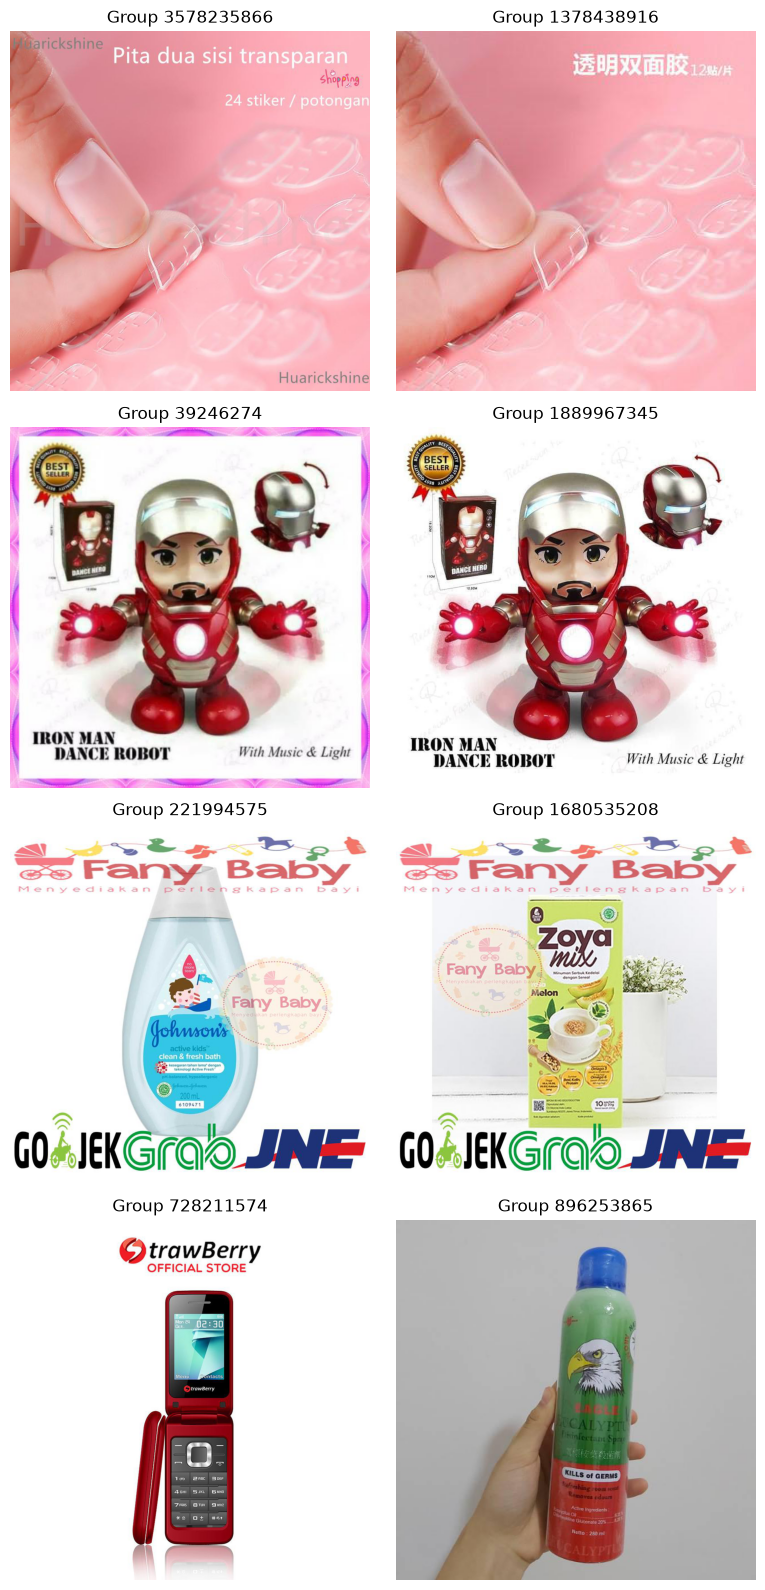

In [15]:
from PIL import Image

def find_image_root():
    candidates = [
        Path("train_images"),
        Path("train_images_34250"),
        Path(r'D:\weq-preview\madatory task 1\train_images'),
        Path("train"),
        Path("../train_images"),
        Path("../images"),
    ]
    for p in candidates:
        if p.exists() and p.is_dir():
            return p
    return None

IMAGE_ROOT = find_image_root()
print("Image folder:", IMAGE_ROOT)

def locate_image(filename):
    if IMAGE_ROOT is None:
        return None
    p = IMAGE_ROOT / str(filename)
    if p.exists():
        return p
    # Some datasets store image extensions separately.
    for ext in [".jpg", ".jpeg", ".png", ".webp"]:
        q = IMAGE_ROOT / (str(filename) + ext)
        if q.exists():
            return q
    return None

if IMAGE_ROOT is not None and len(visual_similar_different_groups) > 0:
    shown = visual_similar_different_groups.head(4)
    fig, axes = plt.subplots(len(shown), 2, figsize=(8, 4 * len(shown)))
    if len(shown) == 1:
        axes = np.array([axes])
    for r, (_, row) in enumerate(shown.iterrows()):
        for c, col in enumerate(["image_1", "image_2"]):
            path = locate_image(row[col])
            ax = axes[r, c]
            if path is not None:
                ax.imshow(Image.open(path))
                ax.axis("off")
            else:
                ax.text(0.5, 0.5, f"Image not found\n{row[col]}",
                        ha="center", va="center")
                ax.axis("off")
        axes[r, 0].set_title(f"Group {row['group_1']}")
        axes[r, 1].set_title(f"Group {row['group_2']}")
    plt.tight_layout()
    plt.show()
else:
    print("No image folder was found. Place the training images in a recognised folder to display them.")

## 8. Noisy or Incomplete Information

Short titles are used as a simple way to inspect listings with potentially limited textual information. This does not prove that the information is actually incomplete; it identifies examples worth inspecting.

In [16]:
short_titles = train.sort_values("title", key=lambda s: s.str.len()).head(15)

display(short_titles[
    ["posting_id", "image", "title", "label_group"]
])

,posting_id,image,title,label_group
4009,train_2307897736,1e74721f94e2ad18ea841ad9333d4fb3.jpg,fullo,1029271551
29427,train_581412210,dc8e88f6cdd5ba22333cd78ec986e344.jpg,Gamis,181942707
14695,train_3496780456,6ea64a58754b08e5b351901aa815620e.jpg,"Mpek""",2813625930
3598,train_188151610,1b936dae2e3ba88b7222f75b4747e36e.jpg,Nebula,4155543612
30880,train_1820528552,e73ec34c022d2c055137a4425fca2cf3.jpg,ZR-221,3281617558
24107,train_1213162986,b485948e23190b73fb045742937c2dc9.jpg,Tricks,449938131
15327,train_1036569790,735b46e11f8b1e73dcaa795f89d08db1.jpg,Plossa,392699942
23824,train_24061770,b2995ee5343feae52b6362177cd4eaca.jpg,Masker,3951971428
31007,train_2197801383,e8496885b61cb2ea2d8eb6c9998fc133.jpg,ZR-206,1840210388
21902,train_2833307243,a4954ddce8f73466f9968c46f5cd94a3.jpg,ZR-208,622201978


## 9. Other Interesting Properties

### Title language / character patterns

Titles may contain Latin characters, digits, punctuation, and non-ASCII characters. These patterns can make exact text matching unreliable.

,title_length,non_ascii_ratio,digit_count,punctuation_count
count,34250.000000,34250.0,34250.000000,34250.000000
mean,56.163474,0.0,2.474336,1.408409
std,25.100492,0.0,4.024089,2.000447
min,5.000000,0.0,0.000000,0.000000
25%,36.000000,0.0,0.000000,0.000000
50%,53.000000,0.0,2.000000,1.000000
75%,73.000000,0.0,3.000000,2.000000
max,357.000000,0.0,120.000000,73.000000


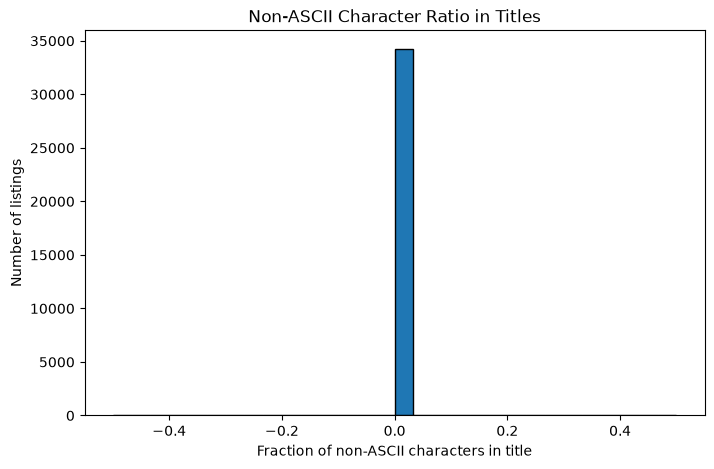

In [17]:
def non_ascii_ratio(text):
    text = str(text)
    return sum(ord(c) > 127 for c in text) / max(len(text), 1)

train_analysis = train.copy()
train_analysis["title_length"] = train_analysis["title"].str.len()
train_analysis["non_ascii_ratio"] = train_analysis["title"].map(non_ascii_ratio)
train_analysis["digit_count"] = train_analysis["title"].str.count(r"\d")
train_analysis["punctuation_count"] = train_analysis["title"].str.count(r"[^\w\s]")

display(train_analysis[
    ["title_length", "non_ascii_ratio", "digit_count", "punctuation_count"]
].describe())

plt.figure(figsize=(8, 5))
plt.hist(train_analysis["non_ascii_ratio"], bins=30, edgecolor="black")
plt.xlabel("Fraction of non-ASCII characters in title")
plt.ylabel("Number of listings")
plt.title("Non-ASCII Character Ratio in Titles")
plt.show()

## 10. Identify the Main Matching Challenges

Based on the exploration above, the main challenges to investigate are:

1. **Noisy product titles** — titles can contain extra words, punctuation, formatting, and seller-specific text.
2. **Different languages / character patterns** — titles are not necessarily written in one consistent language or character set.
3. **Abbreviations and variants** — equivalent products may be described using different wording.
4. **Visually similar products** — different product identities can have similar-looking images.
5. **Different image presentations** — the same product may appear in different images/backgrounds/angles.
6. **Duplicate images and repeated information** — exact or near-duplicate images can occur across listings.
7. **Missing or limited information** — short titles may provide little information for matching.
8. **Large variation in group size** — some product groups contain many listings while others contain only a few.

These observations should be supported by the statistics and examples generated above rather than by the plots alone.

## 11. Answers to the Questions to Consider

### What makes two listings belong to the same product?
In the labelled training data, the same `label_group` identifies listings belonging to the same product group. The listings may still differ in their titles and images.

### Can product titles alone reliably determine whether two listings match?
The exploration shows why this is difficult: titles can be duplicated, highly similar across different groups, short, multilingual, noisy, or formatted differently. Therefore, titles alone should not be assumed to be perfectly reliable.

### Can images alone reliably determine whether two listings match?
Not necessarily. The same product can have different image representations, while visually similar images can correspond to different product identities.

### What types of examples are likely to be difficult for a machine learning model?
Examples with very similar titles but different groups, visually similar images from different groups, different images for the same group, short/noisy titles, and large variations in product presentation are likely to be difficult.

### What information could potentially be useful?
The dataset provides listing IDs, image information, image pHash values, titles, and product-group labels. These are useful signals to investigate in later matching work.